In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from IPython.terminal.shortcuts.filters import PassThrough

df=pd.read_csv("IPLPlayerStat.csv")
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [2]:
df.shape

(605, 17)

In [3]:
df['runs'].describe()

count     605.000000
mean      464.428099
std       985.272855
min         0.000000
25%        15.000000
50%        73.000000
75%       326.000000
max      6634.000000
Name: runs, dtype: float64

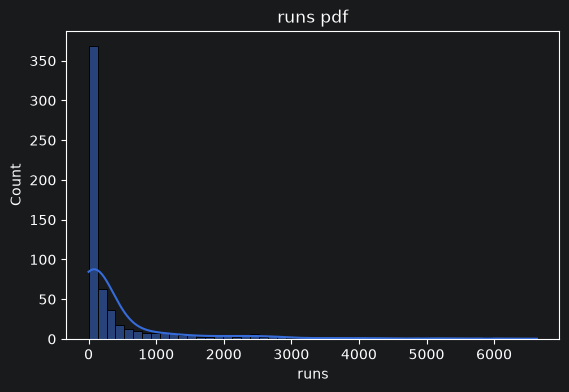

In [5]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sb.histplot(df["runs"],kde=True)
plt.title("runs pdf")
plt.show()

In [6]:
df["runs_log"]=np.log1p(df["runs"])
df["runs_log10"]=df["runs_log"]/np.log(10)
df[["runs","runs_log","runs_log10"]].head(10)

,runs,runs_log,runs_log10
0,280,5.638355,2.448706
1,161,5.087596,2.209515
2,4,1.609438,0.698970
3,53,3.988984,1.732394
4,25,3.258097,1.414973
5,4,1.609438,0.698970
6,62,4.143135,1.799341
7,35,3.583519,1.556303
8,108,4.691348,2.037426
9,362,5.894403,2.559907


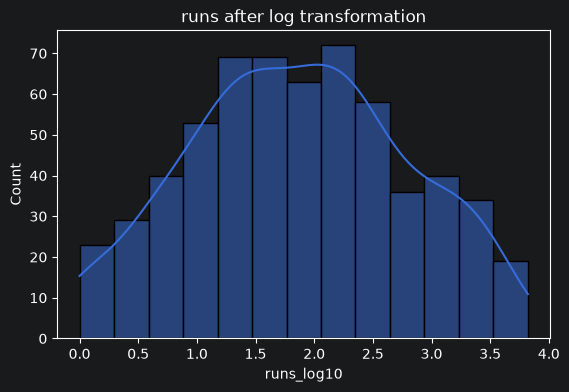

In [7]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.title("runs after log transformation")
sb.histplot(df["runs_log10"],kde=True)
plt.show()

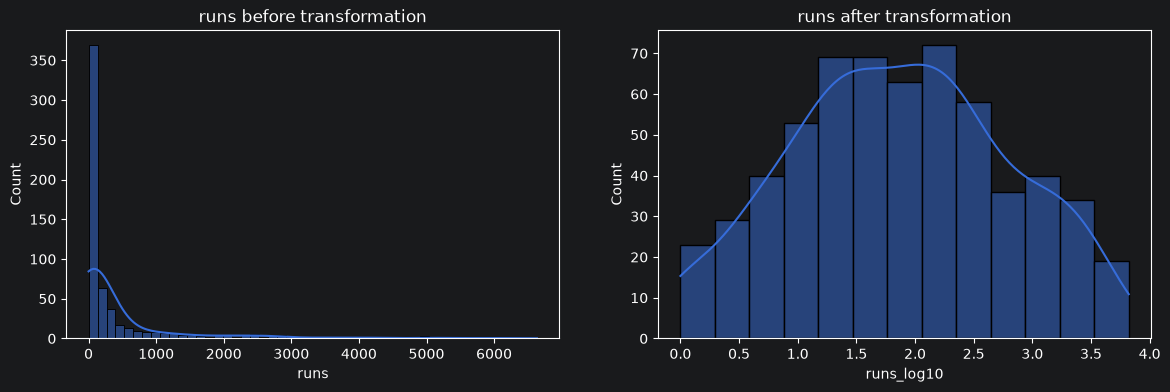

In [8]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].set_title("runs before transformation")
sb.histplot(df["runs"],kde=True,ax=axes[0])
axes[1].set_title("runs after transformation")
sb.histplot(df["runs_log10"],kde=True,ax=axes[1])
plt.show()

power transformation

In [9]:
from sklearn.preprocessing import PowerTransformer
df=pd.read_csv("IPLPlayerStat.csv")
df["matches"].describe()

count    605.000000
mean      32.869421
std       42.215050
min        1.000000
25%        6.000000
50%       14.000000
75%       43.000000
max      221.000000
Name: matches, dtype: float64

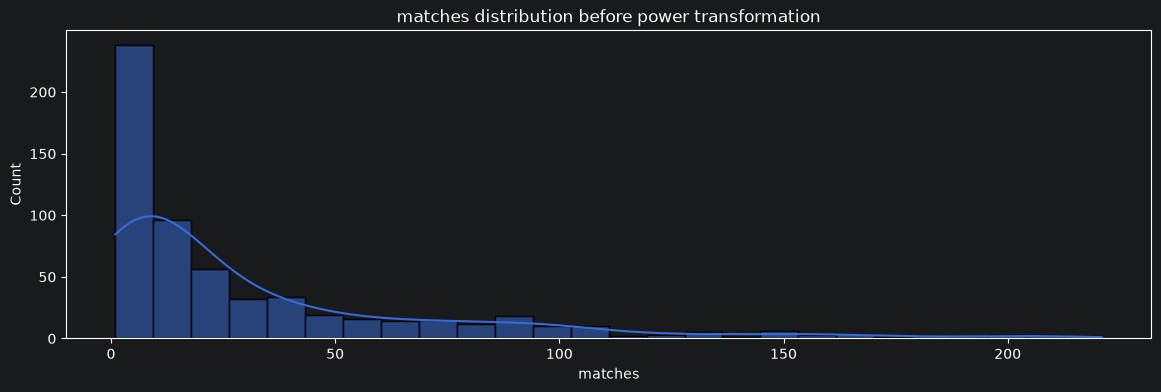

In [10]:
plt.figure(figsize=(14,4))
sb.histplot(df["matches"],kde=True)
plt.title("matches distribution before power transformation")
plt.show()

In [16]:
pt=PowerTransformer(method="yeo-johnson")
df["matches_power"]=pt.fit_transform(df[["matches"]].astype(int))
print(pt.lambdas_)

[-0.04910143]


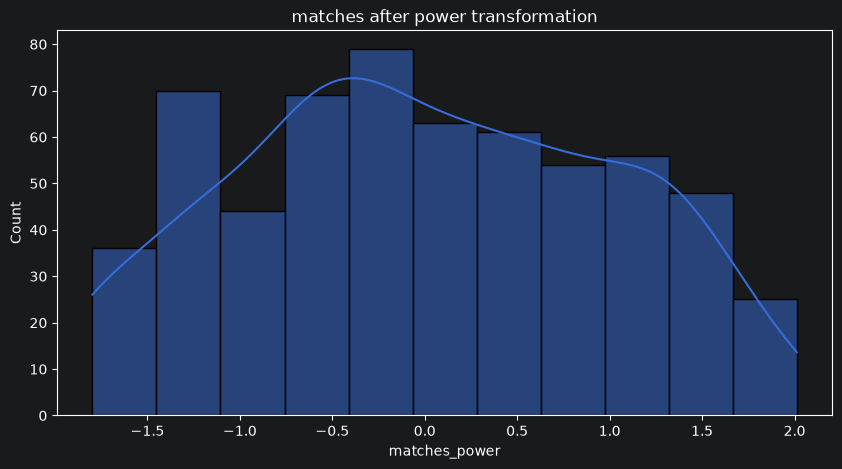

In [17]:
plt.figure(figsize=(10,5))
plt.title("matches after power transformation")
sb.histplot(df["matches_power"],kde=True)
plt.show()

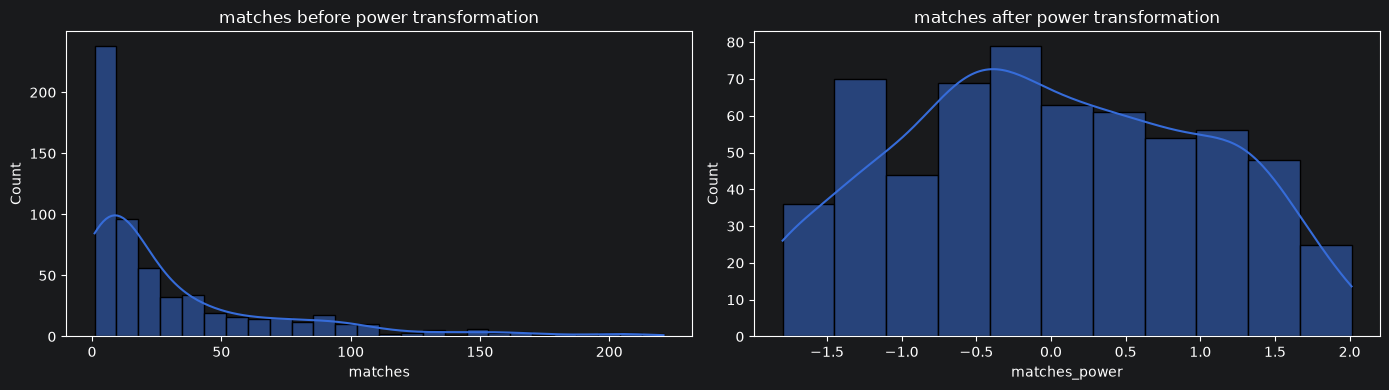

In [19]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].set_title("matches before power transformation")
sb.histplot(df["matches"],kde=True,ax=axes[0])
axes[1].set_title("matches after power transformation")
sb.histplot(df["matches_power"],kde=True,ax=axes[1])
plt.tight_layout()
plt.show()

In [20]:
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [21]:
x=df[["team1_runs"]]
x.head()

,team1_runs
0,131
1,177
2,205
3,158
4,210


In [24]:
bins=[0,120,160,200,df["team1_runs"].max()]
labels=['low','medium','high','very_high']
df['runs_category']=pd.cut(
    df["team1_runs"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)
df[["team1_runs","runs_category"]].head(10)

,team1_runs,runs_category
0,131,medium
1,177,high
2,205,very_high
3,158,medium
4,210,very_high
5,128,medium
6,210,very_high
7,137,medium
8,171,high
9,193,high


In [30]:
df["runs_category"].value_counts().sort_index()
#df["runs_category"].value_counts().sort_values()

runs_category
low           13
medium        77
high         148
very_high    129
Name: count, dtype: int64

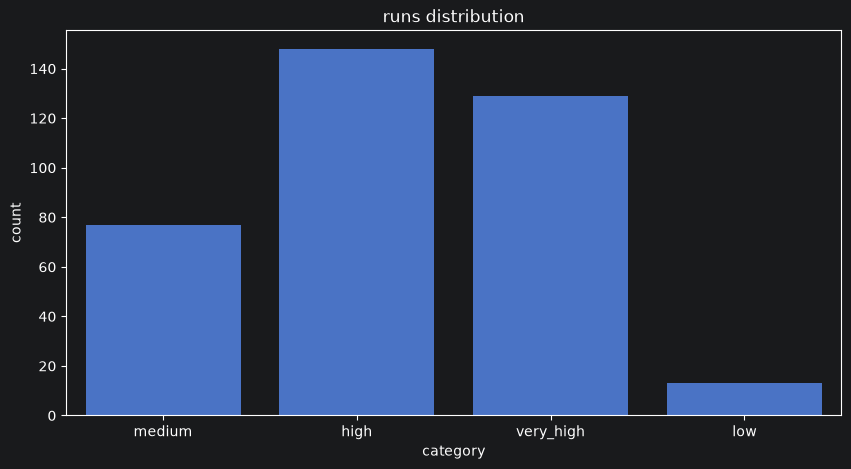

In [36]:
plt.figure(figsize=(10,5))
plt.title("runs distribution")
plt.xlabel("category")
plt.ylabel("count")
sb.countplot(x=df["runs_category"],data=df,order=df['runs_category'].values)
plt.show()

In [37]:
comparison=df[["team1_runs","runs_category"]]
comparison.head(10)

,team1_runs,runs_category
0,131,medium
1,177,high
2,205,very_high
3,158,medium
4,210,very_high
5,128,medium
6,210,very_high
7,137,medium
8,171,high
9,193,high


In [38]:
from sklearn.preprocessing import Binarizer
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [41]:
x=df[["team1_runs"]]
x.head()

,team1_runs
0,131
1,177
2,205
3,158
4,210


In [40]:
binarizer=Binarizer(threshold=160)
x_binary=binarizer.fit_transform(x)
x_binary=pd.DataFrame(x_binary,columns=["team1_runs"])
x_binary.head()

,team1_runs
0,0
1,1
2,1
3,0
4,1


In [42]:
comparison=pd.DataFrame({
    "original": x['team1_runs'],
    "binarized": x_binary['team1_runs']
})
comparison.head(10)

,original,binarized
0,131,0
1,177,1
2,205,1
3,158,0
4,210,1
5,128,0
6,210,1
7,137,0
8,171,1
9,193,1


In [43]:
comparison['binarized'].value_counts()

binarized
1    277
0     90
Name: count, dtype: int64

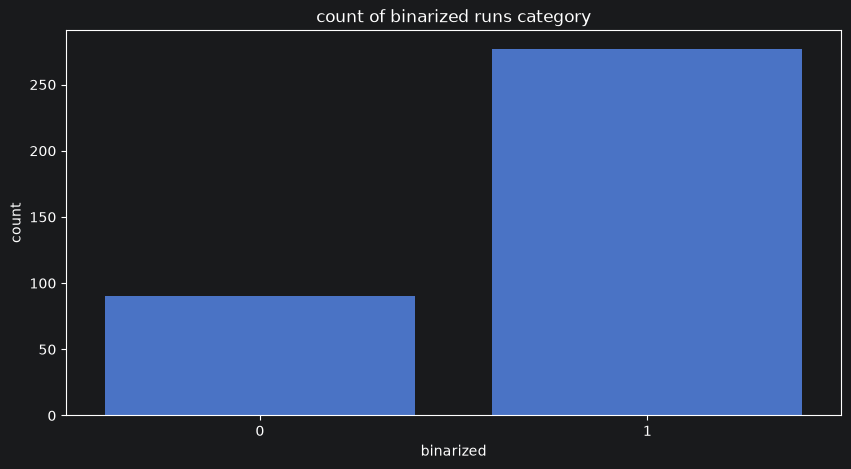

In [44]:
plt.figure(figsize=(10,5))
sb.countplot(x=comparison['binarized'],data=comparison)
plt.title("count of binarized runs category")
plt.show()

column transformer

In [45]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [48]:
x=df[["team1_runs","toss_decision","team1_wickets","win_by_wickets"]]
x.head()

,team1_runs,toss_decision,team1_wickets,win_by_wickets
0,131,field,5,6
1,177,field,5,4
2,205,field,2,5
3,158,field,6,5
4,210,field,6,0


In [50]:
from sklearn.pipeline import Pipeline
transformer=ColumnTransformer(
    transformers=[
        ('num',SimpleImputer(strategy='mean'),['team1_runs']),
        ('scale',StandardScaler(),['team1_wickets']),
        ('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder())]),['toss_decision']),
        ('details','passthrough',['win_by_wickets'])
    ]
)
x_transformed=transformer.fit_transform(x)
print(type(x_transformed))
x_transformed=pd.DataFrame(x_transformed,columns=['team1_runs','team1_wickets','toss_decision_bat','toss_decision_field','win_by_wickets'])
x_transformed

<class 'numpy.ndarray'>


,team1_runs,team1_wickets,toss_decision_bat,toss_decision_field,win_by_wickets
0,131.0,-0.572377,0.0,1.0,6.0
1,177.0,-0.572377,0.0,1.0,4.0
2,205.0,-1.954365,0.0,1.0,5.0
3,158.0,-0.111714,0.0,1.0,5.0
4,210.0,-0.111714,0.0,1.0,0.0
...,...,...,...,...,...
362,203.0,-0.572377,0.0,1.0,0.0
363,254.0,-0.572377,0.0,1.0,0.0
364,243.0,0.809612,0.0,1.0,0.0
365,214.0,-0.111714,1.0,0.0,7.0


In [51]:
print("original shape",x.shape)
print("transformed shape",x_transformed.shape)

original shape (367, 4)
transformed shape (367, 5)
